# Load Trained Model & Visualize Results

This notebook loads a pre-trained CORAL ordinal regression model and evaluates it on the test set without retraining.

**Steps:**
1. Load configuration and data
2. Define model architecture
3. Load trained checkpoint (.pth)
4. Run inference on test set
5. Visualize confusion matrix and metrics

In [1]:
# --- Imports ---
import json
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

import config

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


In [2]:
# --- Load paths and metadata ---
OUTPUT_ROOT = Path(config.OUTPUT_ROOT)
SEQ_DIR = OUTPUT_ROOT / config.FINAL_SEQUENCE_SUBDIR
MASK_DIR = OUTPUT_ROOT / config.INTERPOLATION_MASK_SUBDIR
META_DIR = OUTPUT_ROOT / config.FINAL_METADATA_SUBDIR
SPLIT_DIR = OUTPUT_ROOT / config.FINAL_SPLIT_SUBDIR

PROCESSED_METADATA_CSV = META_DIR / "processed_metadata.csv"
SPLITS_JSON = SPLIT_DIR / "dataset_splits.json"

# Load processed metadata
processed_df = pd.read_csv(PROCESSED_METADATA_CSV)
with open(SPLITS_JSON, "r", encoding="utf-8") as f:
    split_map = json.load(f)

def resolve_split(row) -> str:
    if bool(row.get("augmented", False)):
        return "train"
    vid = str(row["video_id"])
    return split_map.get(vid, "train")

processed_df["split"] = processed_df.apply(resolve_split, axis=1)

print("Loaded metadata:")
print(f"  Total samples: {len(processed_df)}")
print(f"  Split counts:\n{processed_df['split'].value_counts()}")

Loaded metadata:
  Total samples: 332
  Split counts:
split
train    272
val       30
test      30
Name: count, dtype: int64


In [3]:
# --- Define Dataset ---
BAND_ID_TO_RANK = {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}

class SwingBandDataset(Dataset):
    def __init__(self, df: pd.DataFrame, split: str):
        self.df = df[df["split"] == split].reset_index(drop=True)
        self.split = split

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        seq_path = Path(config.BASE_DIR) / Path(str(row["sequence_path"]))
        
        npz = np.load(seq_path, allow_pickle=True)
        X_joint = npz["X_joint"].astype(np.float32)
        X_global = npz["X_global"].astype(np.float32)
        band_id = int(npz["y"].astype(np.int64))
        y_rank = int(BAND_ID_TO_RANK[band_id])

        mask_path = Path(config.BASE_DIR) / Path(str(row["interpolation_mask_path"]))
        interp_mask = None
        if mask_path.exists():
            m = np.load(mask_path, allow_pickle=True)
            interp_mask = m["interpolation_mask"].astype(bool)

        X_joint_t = torch.from_numpy(X_joint)
        X_global_t = torch.from_numpy(X_global)
        y_t = torch.tensor(y_rank, dtype=torch.long)

        meta = {
            "video_id": str(row["video_id"]),
            "env": str(row["env"]),
            "band_str": str(row["band"]),
            "band_id": band_id,
        }

        return X_joint_t, X_global_t, y_t, meta, interp_mask

def collate_fn(batch):
    Xj, Xg, y, meta, masks = zip(*batch)
    Xj = torch.stack(Xj, dim=0)
    Xg = torch.stack(Xg, dim=0)
    y = torch.stack(y, dim=0)
    return Xj, Xg, y, list(meta), list(masks)

# Create test dataset
test_ds = SwingBandDataset(processed_df, "test")
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=0, collate_fn=collate_fn)

print(f"Test samples: {len(test_ds)}")

Test samples: 30


In [4]:
# --- Define Model Architecture (must match training) ---

class CoralLayer(nn.Module):
    """CORAL: Consistent Rank Logits layer with shared weight + learnable biases."""
    def __init__(self, in_features, num_thresholds=4):
        super().__init__()
        self.fc = nn.Linear(in_features, 1, bias=False)
        self.bias = nn.Parameter(torch.zeros(num_thresholds))
    
    def forward(self, x):
        s = self.fc(x)
        return s + self.bias.view(1, -1)


class BandOrdinalModel(nn.Module):
    def __init__(self, hidden_dim=128, lstm_layers=1, dropout=0.35, num_ordinal_logits=4, num_classes=5):
        super().__init__()
        joint_in = 33 * config.POSE_JOINT_FEATURE_DIM

        self.joint_fc = nn.Sequential(
            nn.Linear(joint_in, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout),
        )

        self.global_mlp = nn.Sequential(
            nn.Linear(config.POSE_GLOBAL_FEATURE_DIM, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout),
        )

        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=0.0,
            bidirectional=True,
        )

        self.attn = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

        self.gate = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
        )

        fused_dim = hidden_dim * 2 + hidden_dim

        self.fused_fc = nn.Sequential(
            nn.Linear(fused_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout),
        )

        self.coral = CoralLayer(hidden_dim, num_thresholds=num_ordinal_logits)
        self.cls_head = nn.Linear(hidden_dim, num_classes)

    def forward(self, X_joint, X_global):
        B, T, J, D = X_joint.shape

        xj = X_joint.reshape(B, T, J * D)
        xj = self.joint_fc(xj)

        out, _ = self.lstm(xj)

        w = self.attn(out)
        w = torch.softmax(w, dim=1)
        seq = (out * w).sum(dim=1)

        g = X_global.mean(dim=1)
        g = self.global_mlp(g)
        g = g * self.gate(g)

        fused = torch.cat([seq, g], dim=-1)
        h = self.fused_fc(fused)

        logits_ord = self.coral(h)
        logits_cls = self.cls_head(h)

        return logits_ord, logits_cls

print("✓ Model architecture defined")

✓ Model architecture defined


In [5]:
# --- Load Trained Model Checkpoint ---

# Path to checkpoint (change this to your specific checkpoint file)
checkpoint_path = OUTPUT_ROOT / "checkpoints" / "golf_prediction.pth"

# Alternative: load specific timestamp checkpoint

if not checkpoint_path.exists():
    print(f"Checkpoint not found: {checkpoint_path}")
    print("\nAvailable checkpoints:")
    checkpoint_dir = OUTPUT_ROOT / "checkpoints"
    if checkpoint_dir.exists():
        for f in checkpoint_dir.glob("*.pth"):
            print(f"  - {f.name}")
else:
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    
    # Create model and load state
    model = BandOrdinalModel().to(DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    print(f"✓ Model loaded from: {checkpoint_path.name}")
    print(f"  - Best val loss: {checkpoint['best_val_loss']:.4f}")
    print(f"  - Trained epochs: {checkpoint['epoch']}")
    print(f"  - Model config: {checkpoint['model_config']}")

✓ Model loaded from: golf_prediction.pth
  - Best val loss: 0.8922
  - Trained epochs: 20
  - Model config: {'hidden_dim': 128, 'lstm_layers': 1, 'dropout': 0.35, 'num_ordinal_logits': 4, 'num_classes': 5}


In [6]:
# --- Inference Helper Function ---

def infer_rank_from_ordinal(logits_ord):
    """
    Convert ordinal logits to rank predictions using expected value.
    logits_ord: (B, 4)
    Returns: (B,) rank predictions in [0..4]
    """
    probs = torch.sigmoid(logits_ord)
    expected = probs.sum(dim=1)
    pred_rank = torch.round(expected).long()
    pred_rank = torch.clamp(pred_rank, 0, 4)
    return pred_rank

print("✓ Inference function defined")

✓ Inference function defined


In [12]:
# --- Run Inference on Test Set ---

RANK_TO_BAND = {0: "1_2", 1: "2_4", 2: "4_6", 3: "6_8", 4: "8_10"}

model.eval()
all_pred_ranks = []
all_true_ranks = []
all_video_ids = []
all_envs = []
all_band_str = []

print("Running inference on test set...")
with torch.no_grad():
    for Xj, Xg, y_rank, meta, masks in tqdm(test_loader):
        Xj = Xj.to(DEVICE)
        Xg = Xg.to(DEVICE)
        y_rank = y_rank.to(DEVICE)

        logits_ord, logits_cls = model(Xj, Xg)
        pred_rank = infer_rank_from_ordinal(logits_ord)

        all_pred_ranks.extend(pred_rank.cpu().numpy().tolist())
        all_true_ranks.extend(y_rank.cpu().numpy().tolist())

        for m in meta:
            all_video_ids.append(m["video_id"])
            all_envs.append(m["env"])
            all_band_str.append(m["band_str"])

print(f"✓ Inference completed on {len(all_pred_ranks)} samples")

Running inference on test set...


100%|██████████| 2/2 [00:00<00:00, 24.35it/s]

✓ Inference completed on 30 samples


In [8]:
# --- Visualize Results: Classification Report & Metrics ---

# Convert ranks to band labels
all_bands = [RANK_TO_BAND[i] for i in range(5)]
true_band_labels = [RANK_TO_BAND[r] for r in all_true_ranks]
pred_band_labels = [RANK_TO_BAND[r] for r in all_pred_ranks]

print("=" * 70)
print("CORAL ORDINAL REGRESSION RESULTS (Test Set)")
print("=" * 70)
print(classification_report(true_band_labels, pred_band_labels, target_names=all_bands, digits=4))

# Compute MAE in rank space
mae_rank = np.mean(np.abs(np.array(all_pred_ranks) - np.array(all_true_ranks)))
print(f"\nMean Absolute Error (Rank Space): {mae_rank:.4f}")

# Overall accuracy
acc = np.mean(np.array(all_pred_ranks) == np.array(all_true_ranks))
print(f"Overall Accuracy: {acc:.4f}")

# Per-band accuracy
print("\nPer-Band Accuracy:")
for i in range(5):
    mask = np.array(all_true_ranks) == i
    if mask.sum() > 0:
        band_acc = np.mean(np.array(all_pred_ranks)[mask] == i)
        print(f"  {RANK_TO_BAND[i]:5s}: {band_acc:.4f} ({mask.sum():3d} samples)")
print("=" * 70)

CORAL ORDINAL REGRESSION RESULTS (Test Set)
              precision    recall  f1-score   support

         1_2     0.4444    0.5714    0.5000         7
         2_4     0.3333    0.4000    0.3636         5
         4_6     0.6667    0.4000    0.5000         5
         6_8     0.6667    0.5714    0.6154         7
        8_10     0.8333    0.8333    0.8333         6

    accuracy                         0.5667        30
   macro avg     0.5889    0.5552    0.5625        30
weighted avg     0.5926    0.5667    0.5709        30


Mean Absolute Error (Rank Space): 0.6000
Overall Accuracy: 0.5667

Per-Band Accuracy:
  1_2  : 0.5714 (  7 samples)
  2_4  : 0.4000 (  5 samples)
  4_6  : 0.4000 (  5 samples)
  6_8  : 0.5714 (  7 samples)
  8_10 : 0.8333 (  6 samples)


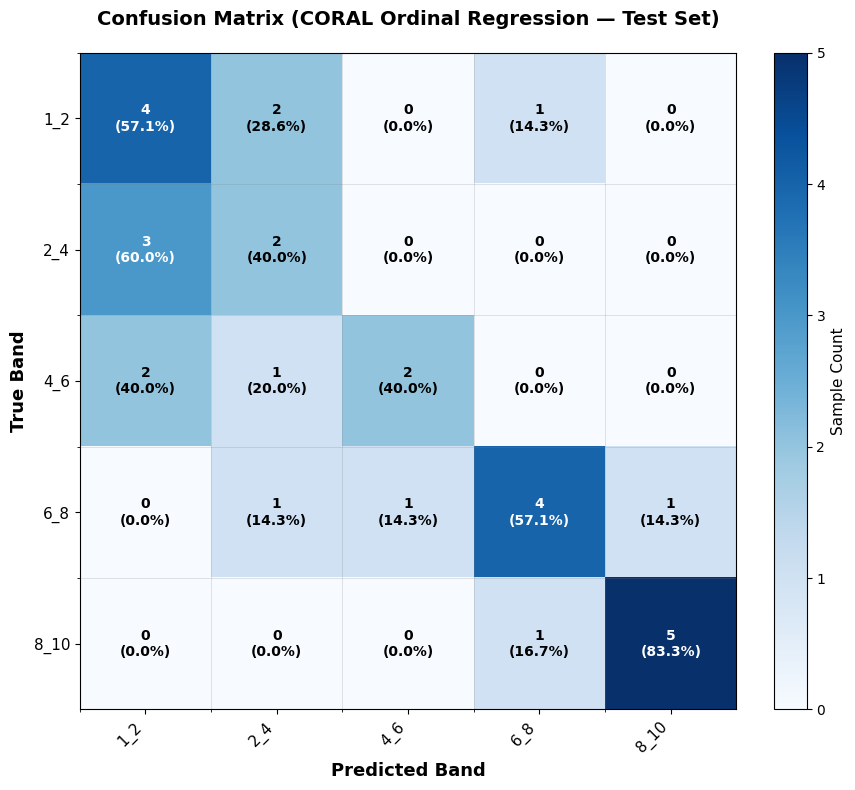


✓ Confusion matrix saved to: D:\DAI_HOC\THI\DATASTORM 2025\DATASTORM---QUAQUYT\results\test_confusion_matrix.png


In [9]:
# --- Visualize Confusion Matrix ---

cm = confusion_matrix(all_true_ranks, all_pred_ranks, labels=list(range(5)))

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(cm, cmap="Blues")
max_val = cm.max()

# Add text annotations
for i in range(5):
    for j in range(5):
        value = cm[i, j]
        # Calculate percentage
        row_total = cm[i].sum()
        pct = (value / row_total * 100) if row_total > 0 else 0
        
        # Show count and percentage
        text = f"{value}\n({pct:.1f}%)"
        ax.text(
            j, i, text,
            ha="center", va="center",
            color="white" if value > max_val * 0.5 else "black",
            fontsize=10, weight="bold"
        )

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(all_bands, rotation=45, ha="right", fontsize=11)
ax.set_yticklabels(all_bands, fontsize=11)

ax.set_xlabel("Predicted Band", fontsize=13, weight="bold")
ax.set_ylabel("True Band", fontsize=13, weight="bold")
ax.set_title("Confusion Matrix (CORAL Ordinal Regression — Test Set)", fontsize=14, weight="bold", pad=20)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Sample Count", fontsize=11)

# Add grid
ax.set_xticks(np.arange(5) - 0.5, minor=True)
ax.set_yticks(np.arange(5) - 0.5, minor=True)
ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.show()

# Save figure
fig_path = OUTPUT_ROOT / "test_confusion_matrix.png"
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Confusion matrix saved to: {fig_path}")

In [10]:
# --- Save Predictions to CSV ---

pred_df = pd.DataFrame({
    "video_id": all_video_ids,
    "env": all_envs,
    "true_rank": all_true_ranks,
    "pred_rank": all_pred_ranks,
    "true_band": true_band_labels,
    "pred_band": pred_band_labels,
    "correct": np.array(all_pred_ranks) == np.array(all_true_ranks),
    "abs_error": np.abs(np.array(all_pred_ranks) - np.array(all_true_ranks))
})

out_csv = OUTPUT_ROOT / "test_predictions_loaded_model.csv"
pred_df.to_csv(out_csv, index=False)

print(f"✓ Predictions saved to: {out_csv}")
print(f"\nPrediction summary:")
print(f"  Total samples: {len(pred_df)}")
print(f"  Correct predictions: {pred_df['correct'].sum()} ({pred_df['correct'].mean():.2%})")
print(f"  Mean absolute error: {pred_df['abs_error'].mean():.4f}")

# Show sample predictions
print(f"\nSample predictions (first 10):")
print(pred_df[['video_id', 'true_band', 'pred_band', 'correct', 'abs_error']].head(10).to_string(index=False))

✓ Predictions saved to: D:\DAI_HOC\THI\DATASTORM 2025\DATASTORM---QUAQUYT\results\test_predictions_loaded_model.csv

Prediction summary:
  Total samples: 30
  Correct predictions: 17 (56.67%)
  Mean absolute error: 0.6000

Sample predictions (first 10):
             video_id true_band pred_band  correct  abs_error
Backside-8767-14_no02       1_2       1_2     True          0
Backside-8767-14_no03       1_2       2_4    False          1
Backside-8767-16_no02       1_2       1_2     True          0
Backside-8767-17_no00       1_2       2_4    False          1
     Side-6020-7_no03       1_2       1_2     True          0
     Side-6020-9_no03       1_2       1_2     True          0
 Backside-8767-2_no03       2_4       2_4     True          0
     Side-6020-2_no01       2_4       1_2    False          1
 Backside-8767-6_no02       4_6       1_2    False          2
    Side-6016-18_no00       4_6       4_6     True          0



ERROR ANALYSIS: 13 misclassified samples

Error distribution:
  Off by 1 band(s): 9 samples (69.2%)
  Off by 2 band(s): 3 samples (23.1%)
  Off by 3 band(s): 1 samples (7.7%)

Most common misclassification patterns:
  2_4 → 1_2: 3 samples
  1_2 → 2_4: 2 samples
  4_6 → 1_2: 2 samples
  1_2 → 6_8: 1 samples
  4_6 → 2_4: 1 samples
  6_8 → 2_4: 1 samples
  6_8 → 4_6: 1 samples
  6_8 → 8_10: 1 samples
  8_10 → 6_8: 1 samples

Worst predictions (largest errors):
             video_id     env true_band pred_band  abs_error
     Side-6089-1_no01 outdoor       1_2       6_8          3
 Backside-8767-6_no02  indoor       4_6       1_2          2
     Side-6016-4_no02  indoor       6_8       2_4          2
     Side-6086-1_no01 outdoor       4_6       1_2          2
Backside-8767-14_no03  indoor       1_2       2_4          1


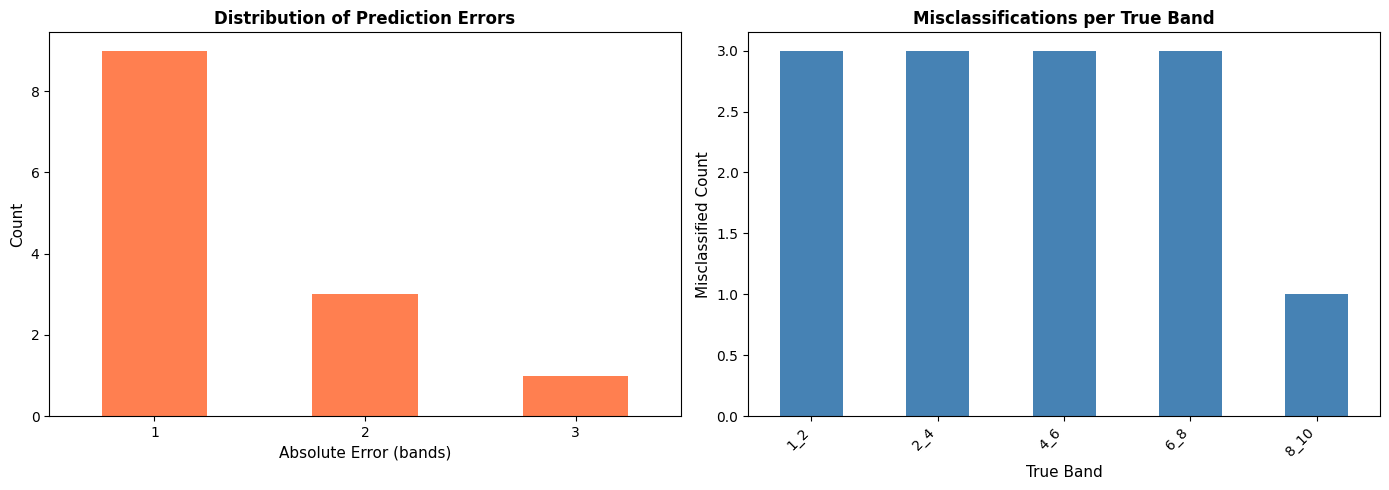

In [11]:
# --- Error Analysis: Visualize Misclassifications ---

# Find misclassified samples
misclassified = pred_df[pred_df['correct'] == False].copy()

if len(misclassified) > 0:
    print(f"\n{'='*70}")
    print(f"ERROR ANALYSIS: {len(misclassified)} misclassified samples")
    print(f"{'='*70}")
    
    # Group by error magnitude
    error_counts = misclassified.groupby('abs_error').size()
    print("\nError distribution:")
    for err, count in error_counts.items():
        print(f"  Off by {int(err)} band(s): {count} samples ({count/len(misclassified):.1%})")
    
    # Most common misclassification patterns
    print("\nMost common misclassification patterns:")
    pattern_counts = misclassified.groupby(['true_band', 'pred_band']).size().sort_values(ascending=False)
    for (true_b, pred_b), count in pattern_counts.head(10).items():
        print(f"  {true_b} → {pred_b}: {count} samples")
    
    # Show worst predictions
    print("\nWorst predictions (largest errors):")
    worst = misclassified.nlargest(5, 'abs_error')
    print(worst[['video_id', 'env', 'true_band', 'pred_band', 'abs_error']].to_string(index=False))
    
    # Visualize error distribution
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Error magnitude distribution
    error_counts.plot(kind='bar', ax=ax1, color='coral')
    ax1.set_xlabel('Absolute Error (bands)', fontsize=11)
    ax1.set_ylabel('Count', fontsize=11)
    ax1.set_title('Distribution of Prediction Errors', fontsize=12, weight='bold')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
    
    # Error by true band
    error_by_band = misclassified.groupby('true_band').size()
    error_by_band.plot(kind='bar', ax=ax2, color='steelblue')
    ax2.set_xlabel('True Band', fontsize=11)
    ax2.set_ylabel('Misclassified Count', fontsize=11)
    ax2.set_title('Misclassifications per True Band', fontsize=12, weight='bold')
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
else:
    print("\n🎉 Perfect predictions! No misclassifications found.")
    
print(f"\n{'='*70}")